In [1]:
import pandas as pd
import xarray as xr
import numpy as np
import string
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MultipleLocator

from metpy.calc import mixing_ratio_from_relative_humidity,specific_humidity_from_mixing_ratio
from metpy.units import units

from cmcrameri import cm

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'Helvetica',
    'Nimbus Sans',
    'Arial',
    'Liberation Sans'
]

data_dir = '../data_out/'
fig_png_dir = '../figures_png/'
fig_pdf_dir = '../figures_pdf/'

In [2]:
def get_df_from_nc(file, var, loc_sel=None):
    ds = xr.open_dataset(file)
    df = pd.DataFrame(ds[var].values, columns=ds.location, index=pd.to_datetime(ds.time,utc=True))[dt_from:dt_to]
    if loc_sel is None:
        return df
    else:
        return df[loc_sel]

## Script settings

In [3]:
#h='2m'
h='5m'

#scope ='H2'
scope ='H3'

In [4]:
# do scope specific settings
if scope == 'H2':   
    scope_name = 'HEFEX II'
    hlines_temp = [2,1]  # positions from below [dotted, solid]
    hlines_qv = [1,0]  # positions from below [dotted, solid]
    
    # Define locations for variable
    loc_temp = ['D316','A309','D305','T303','D293','D285','D281','T275','D273','D269','A267','A267R','A267L','D262','A260','A255','STHE']
    loc_qv = ['A309','T303','T275','A267','A267R','A267L','A260','A255']

    dt_from,dt_to = '2023-08-17', '2023-09-07 10:00'

    file_obs  = f'HEFEX2__Obs_AWS_L1__1h_avg30min_20230816-20230910.nc'
    file_icon = f'HEFEX2__ICON_v370_2030_aws_locations__1h_avg30min_20230815-20230914.nc'
elif scope == 'H3':
    scope_name = 'HEFEX III'
    hlines_temp = [4,3]  # positions from below [dotted, solid]
    hlines_qv = hlines_temp

    loc_temp = ['T303','T272','A245','A244','STHE','IHE']
    loc_qv = loc_temp

    dt_from,dt_to = '2025-08-06', '2025-08-31 23:59'

    file_obs  = f'HEFEX3__Obs_AWS_L1__1h_avg30min_20250805-20250903.nc'
    file_icon = f'HEFEX3__ICON_v370_2030_aws_locations__1h_avg30min_20250805-20250905.nc'
else:
    print('Unknown scope!')

## Get data (ICON & Obs) and resample to daily

The data used for this figure is available at Zenodo:

HEFEX II: [![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.19568035.svg)](https://doi.org/10.5281/zenodo.19568035)

HEFEX III: [![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.19596032.svg)](https://doi.org/10.5281/zenodo.19596032)

In [5]:
df_temp = get_df_from_nc(data_dir + file_obs, f't_2m', loc_temp)
df_rh   = get_df_from_nc(data_dir + file_obs, f'rh_2m', loc_qv)
df_pres = get_df_from_nc(data_dir + file_obs, f'pres', loc_qv)

df_i_temp = get_df_from_nc(data_dir + file_icon, f't_{h}', loc_temp) - 273.15
df_i_qv   = get_df_from_nc(data_dir + file_icon, f'qv_{h}', loc_qv) * 1000

In [6]:
# filter RH data_in and calculate QV
df_rh[df_rh <= 5] = np.nan

df_w = mixing_ratio_from_relative_humidity(df_pres.values * units.hPa, df_temp[loc_qv].values * units.degC, df_rh.values/100)
df_qv = pd.DataFrame(specific_humidity_from_mixing_ratio(df_w).magnitude * 1000, columns=df_rh.columns, index=df_rh.index)

In [7]:
# apply mask of NaN values in Obs to ICON data_in
df_i_temp = df_i_temp.mask(df_temp.isna())
df_i_qv = df_i_qv.mask(df_qv.isna())

In [8]:
# resample all data_in to 1d
df_temp_d = df_temp.resample('1d').mean()
df_i_temp_d = df_i_temp.resample('1d').mean()
df_qv_d = df_qv.resample('1d').mean()
df_i_qv_d = df_i_qv.resample('1d').mean()

In [9]:
def add_loc_superscript(loc, hlines):
    loc_out = loc.copy()
    for i in np.arange(len(loc)-hlines[0],len(loc)-hlines[1]):
        loc_out[i] = f'{loc[i]}'+r'$^a$'
    for i in np.arange(len(loc)-hlines[1],len(loc)):
        loc_out[i] = f'{loc[i]}$^b$'
    return loc_out

loc_temp = add_loc_superscript(loc_temp, hlines_temp)
loc_qv   = add_loc_superscript(loc_qv, hlines_qv)

## Create plots

In [10]:
def get_cmap_norm(bounds,cmap):
    cmap = plt.get_cmap(cmap, len(bounds)-1)
    norm = BoundaryNorm(bounds, ncolors=cmap.N, clip=True)
    return cmap,bounds,norm

def plot_matrix(df,ax,cbar_label):
    im = ax.imshow(df.T, cmap=cmap, norm=norm)
    fig.colorbar(im, ax=ax, shrink=.7, label=cbar_label, boundaries=bounds, ticks=bounds)

    # Overlay hatch where values are NaN
    data = df.T.to_numpy()
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if np.isnan(data[i, j]):
                rect = Rectangle(
                    (j - 0.5, i - 0.5), 1, 1,
                    fill=False, hatch='////', edgecolor='lightgrey', linewidth=0, zorder=-20
                )
                ax.add_patch(rect)

def format_axis(ax, data, loc, hlines):
    ax.set_yticks(range(ny), [loc[i] for i in range(ny)])
    ax.set_xticks(range(0, nx, 3))
    ax.set_xticklabels([data.index[i].strftime('%d.%m.') for i in range(0, nx, 3)])
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    for i,hl in enumerate(hlines):
        if hl > 0:
            ax.axhline(ny-hl-.5, c='white', ls='-', lw=1.5)

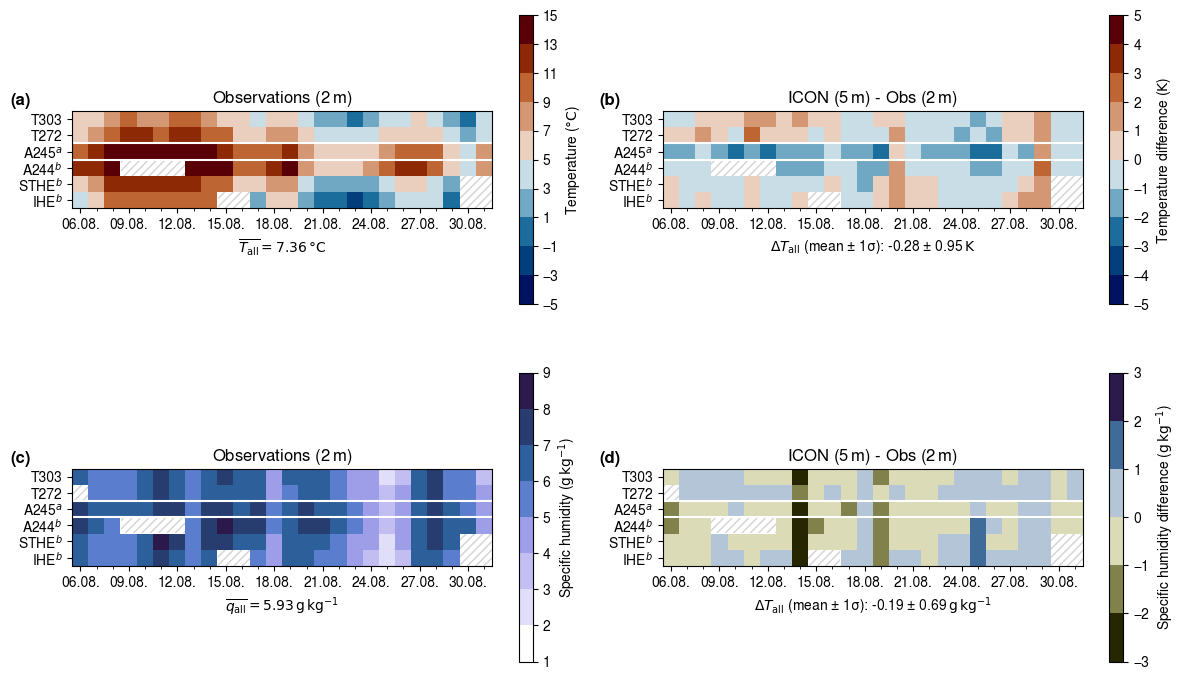

In [11]:
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(12,8))

# TEMP: Obs
ny = len(loc_temp)
nx = len(df_temp_d.index)

cmap,bounds,norm = get_cmap_norm(range(-5,16,2), cm.vik)

ax = axs[0][0]
plot_matrix(df_temp_d,ax,r'Temperature ($\mathrm{{°C}}$)')
ax.set_title(r'Observations (2$\,$m)')
ax.set_xlabel(r'$\overline{T_{\mathrm{all}}}'+fr' = {np.nanmean(df_temp.values):.2f}\,\mathrm{{°C}}$')

# TEMP: ICON-Obs
cmap,bounds,norm = get_cmap_norm(range(-5,6,1), cm.vik)

df_diff = df_i_temp_d-df_temp_d
bias_mean = np.nanmean(df_diff.values).round(2)
bias_std = np.nanstd(df_diff.values).round(2)
ax = axs[0][1]
plot_matrix(df_diff,ax,r'Temperature difference ($\mathrm{K}$)')
ax.set_title(fr'ICON ({h[0]}$\,$m) - Obs (2$\,$m)')
ax.set_xlabel(r'$\Delta T_{\mathrm{all}}$ (mean ± 1σ):'+fr' {bias_mean} ± {bias_std}$\,\mathrm{{K}}$')

for ax in axs[0]:
    format_axis(ax, df_diff, loc_temp, hlines_temp)

# QV: Obs
ny = len(loc_qv)
nx = len(df_qv_d.index)

cmap,bounds,norm = get_cmap_norm(range(1,10,1), cm.devon_r)

ax = axs[1][0]
plot_matrix(df_qv_d,ax,r'Specific humidity ($\mathrm{g\,kg^{-1}}$)')
ax.set_title(r'Observations (2$\,$m)')
ax.set_xlabel(r'$\overline{q_{\mathrm{all}}}'+fr' = {np.nanmean(df_qv.values):.2f}\,\mathrm{{g\,kg^{{-1}}}}$')

# QV: ICON-Obs
cmap,bounds,norm = get_cmap_norm(np.arange(-3,4,1), cm.broc_r)

df_diff = df_i_qv_d-df_qv_d
bias_mean = np.nanmean(df_diff.values).round(2)
bias_std = np.nanstd(df_diff.values).round(2)
ax = axs[1][1]
plot_matrix(df_diff,ax,r'Specific humidity difference ($\mathrm{g\,kg^{-1}}$)')
ax.set_title(fr'ICON ({h[0]}$\,$m) - Obs (2$\,$m)')
ax.set_xlabel(r'$\Delta T_{\mathrm{all}}$ (mean ± 1σ):'+fr' {bias_mean} ± {bias_std}$\,\mathrm{{g\,kg^{{-1}}}}$')

for ax in axs[1]:
    format_axis(ax, df_diff, loc_qv, hlines_qv)

# panel letters 
for ax, letter in zip(axs.flat, string.ascii_lowercase):
    ax.text(
        -0.1, 1.02, f'({letter})',
        transform=ax.transAxes,
        fontsize=12,
        fontweight='bold',
        va='bottom', ha='right'
    )
    
plt.tight_layout()
plt.savefig(fig_png_dir + f'HEF_AWS_ICON_matrix_{scope}_{h}.png', dpi=150, bbox_inches = 'tight', pad_inches = 0)
plt.savefig(fig_pdf_dir + f'HEF_AWS_ICON_matrix_{scope}_{h}.pdf', dpi=300, bbox_inches = 'tight', pad_inches = 0)
plt.show()